# Readout under inter-run drift — TREX goes stale too

The sibling `Composite_drift.ipynb` showed that **static PEC** breaks under gate-noise drift: its
quasi-probability reps are built once, from nominal parameters, and go **stale**. Readout mitigation
has the *same* structure. **TREX** (Twirled Readout Error eXtinction) calibrates the twirled
eigenvalue $\lambda_w$ once and divides it out — so under **readout drift** its calibration goes stale
exactly like PEC's reps.

We compare three levels, all under a drifting readout:
- **noisy** — no readout mitigation (readout floor);
- **TREX static** — $\lambda_w$ calibrated once on the **nominal** readout, then frozen;
- **TREX adaptive** — $\lambda_w$ **recalibrated per run** on the current readout.

Recalibrating per run is the simplest form of *noise-model learning* — a concrete preview of the
re-learning step. Machinery: `qem.readout.trex_success_prob_from_counts` (validated against mitiq's
real TREX in `smoke_drift_trex.py`).

## 1. Setup

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

import sys
from pathlib import Path
for _cand in (Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents):
    if (_cand / "qem" / "__init__.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        break
from qem import *
from qem.noise_models import T1_S, T2_S, EPS_MU_1Q, EPS_MU_2Q

warnings.filterwarnings("ignore")


def counts_of(backend, seed, shots):
    qc = make_benchmark_circuit(seed).copy(); qc.measure_all()
    return backend.run(qc, shots=shots).result().get_counts()


def readout_drift_config(sigma, tau=5.0):
    "Drift ONLY the readout (gate params held at nominal): one OU on readout_scale."
    return DriftConfig(
        t1=OUParams(mu=T1_S, tau=tau, sigma_rel=0.0, lo=1e-9),
        t2=OUParams(mu=T2_S, tau=tau, sigma_rel=0.0, lo=1e-9),
        gate_scale=OUParams(mu=1.0, tau=tau, sigma_rel=0.0, lo=0.0),
        readout_scale=OUParams(mu=1.0, tau=tau, sigma_rel=sigma, lo=0.0),
    )


print("qem loaded. Nominal readout:", READOUT_REALISTIC.p0, READOUT_REALISTIC.p1)
print("Nominal lambda_w (2-qubit ZZ):", round(READOUT_REALISTIC.lambda_support((0, 1)), 4))

qem loaded. Nominal readout: (0.01, 0.013) (0.025, 0.03)
Nominal lambda_w (2-qubit ZZ): 0.9235


## 2. TREX in one line, and how it goes stale

Readout X-twirling symmetrises each qubit's $(p_0,p_1)$ so every $Z_w$ carries a clean eigenvalue

$$\lambda_w = \prod_{i\in w}\big(1 - p_{0,i} - p_{1,i}\big), \qquad
  \langle Z_w\rangle_{\text{noisy}} = \lambda_w^{\text{true}}\,\langle Z_w\rangle_{\text{ideal}}.$$

TREX divides $\langle Z_w\rangle$ by an **estimate** of $\lambda_w$. The regime is set entirely by
*which* $\lambda_w$ it uses:
- divide by $\lambda_w^{\text{true}}$ (**adaptive**, recalibrated) $\to$ exact removal;
- divide by $\lambda_w^{\text{nominal}}$ (**static**, frozen) $\to$ a $\lambda^{\text{true}}/\lambda^{\text{nominal}}$
  ratio error once the readout drifts.

This mirrors PEC exactly: a static characterisation ($\lambda_w$ here, QPRs there) that no longer
matches the drifted channel.

## 3. Persistent readout drift (ideal gate) — the clean staleness curve

Isolate the readout channel: an **ideal gate** (so a perfect method reaches 1.0) and a readout that
has drifted to $s\times$ nominal. As $s$ grows, **static** TREX under-corrects (its frozen $\lambda_w$
is too large) while **adaptive** TREX tracks and stays at 1.0; the un-mitigated **noisy** value is the
readout floor. (Symmetric drift instead spreads static TREX into a *variance* — the readout analogue
of PEC's §5 heavy tails; a persistent offset like here surfaces it as *bias*.)

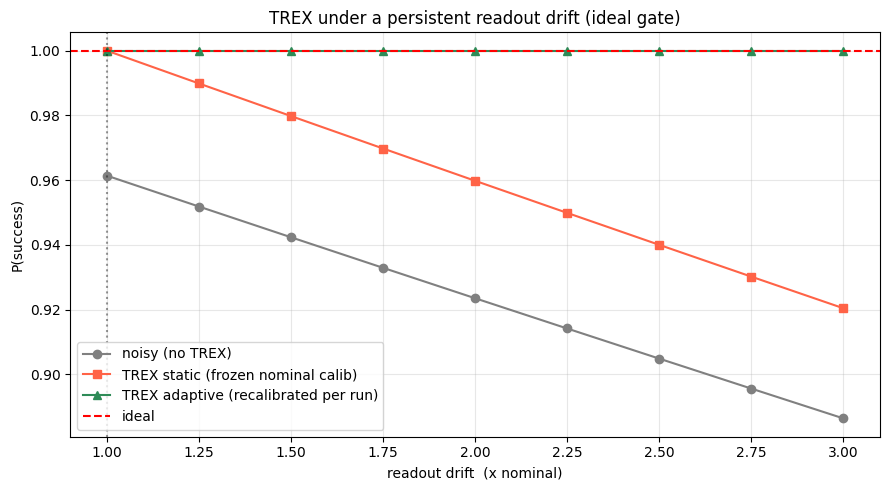

s x nominal    noisy   static  adaptive
       1.00   0.9614   1.0000    1.0000
       1.25   0.9518   0.9899    1.0000
       1.50   0.9423   0.9798    1.0000
       1.75   0.9329   0.9698    1.0000
       2.00   0.9235   0.9598    1.0000
       2.25   0.9142   0.9499    1.0000
       2.50   0.9049   0.9400    1.0000
       2.75   0.8956   0.9302    1.0000
       3.00   0.8864   0.9204    1.0000


In [2]:
ideal = AerSimulator()
tgt = target_key(0)
ci = counts_of(ideal, 0, 40_000)  # ideal gate -> exact point mass on the target

SCALES = np.linspace(1.0, 3.0, 9)  # readout drifted to s x nominal
noisy, static, adaptive = [], [], []
for s in SCALES:
    ro = ReadoutSpec("drift", tuple(min(s * p, 0.49) for p in READOUT_REALISTIC.p0),
                     tuple(min(s * p, 0.49) for p in READOUT_REALISTIC.p1))
    noisy.append(trex_success_prob_from_counts(ci, 40_000, tgt, ro, READOUT_PERFECT))
    static.append(trex_success_prob_from_counts(ci, 40_000, tgt, ro, READOUT_REALISTIC))
    adaptive.append(trex_success_prob_from_counts(ci, 40_000, tgt, ro, ro))

plt.figure(figsize=(9, 5))
plt.plot(SCALES, noisy, "o-", c="gray", label="noisy (no TREX)")
plt.plot(SCALES, static, "s-", c="tomato", label="TREX static (frozen nominal calib)")
plt.plot(SCALES, adaptive, "^-", c="seagreen", label="TREX adaptive (recalibrated per run)")
plt.axhline(1.0, ls="--", c="r", lw=1.5, label="ideal")
plt.axvline(1.0, ls=":", c="k", alpha=0.4)
plt.xlabel("readout drift  (x nominal)"); plt.ylabel("P(success)")
plt.title("TREX under a persistent readout drift (ideal gate)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"{'s x nominal':>11s} {'noisy':>8s} {'static':>8s} {'adaptive':>9s}")
for s, n, st, a in zip(SCALES, noisy, static, adaptive):
    print(f"{s:>11.2f} {n:>8.4f} {st:>8.4f} {a:>9.4f}")

## 4. Full stack under drift — realistic picture

Now the realistic model: composite **gate** noise (nominal) **+** a readout drifted to $2\times$ (a
plausible "stale-calibration moment"). Averaged over circuits:
- **noisy** = gate + readout floor;
- **TREX static** = removes only what the frozen $\lambda_w$ predicts $\to$ partial;
- **TREX adaptive** = removes readout exactly $\to$ lands at the **gate floor** (gate noise remains).

To reach 1.0 you compose **adaptive TREX $\circ$ ZNE** (readout by TREX, gate noise by the
extrapolation), exactly the orthogonal complementarity of `Composite_readout_TREX.ipynb` — but the
readout leg must be **adaptive** under drift.

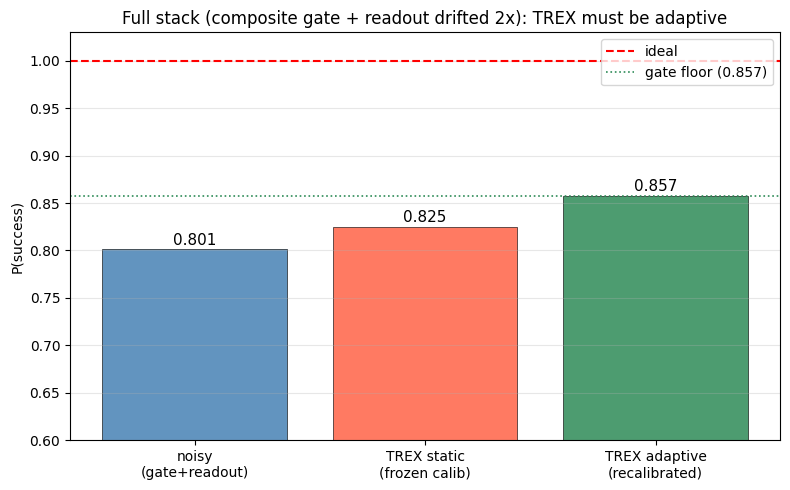

compose adaptive TREX o ZNE to also clear the gate floor -> ~1.0 (cf. Composite_readout_TREX).


In [3]:
RO_BAD = ReadoutSpec("bad", tuple(2 * p for p in READOUT_REALISTIC.p0),
                     tuple(2 * p for p in READOUT_REALISTIC.p1))  # readout drifted to 2x
seeds = range(12)
SHOTS_ = 20_000
gate_nm = SPEC_COMPOSITE.build_noise_model()               # nominal composite gate
full_nm = composite_noise_model_from_params(T1_S, T2_S, EPS_MU_1Q, EPS_MU_2Q, RO_BAD)
gate_bk, full_bk = AerSimulator(noise_model=gate_nm), AerSimulator(noise_model=full_nm)

pn, ps, pa = [], [], []
for s in seeds:
    tgt_s = target_key(s)
    cg = counts_of(gate_bk, s, SHOTS_)
    pn.append(success_prob(full_bk, s, SHOTS_))                                       # noisy
    ps.append(trex_success_prob_from_counts(cg, SHOTS_, tgt_s, RO_BAD, READOUT_REALISTIC))  # static
    pa.append(trex_success_prob_from_counts(cg, SHOTS_, tgt_s, RO_BAD, RO_BAD))              # adaptive

means = [np.mean(pn), np.mean(ps), np.mean(pa)]
labels = ["noisy\n(gate+readout)", "TREX static\n(frozen calib)", "TREX adaptive\n(recalibrated)"]
colors = ["steelblue", "tomato", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, means, color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.005, f"{m:.3f}", ha="center", fontsize=11)
ax.axhline(1.0, ls="--", c="r", lw=1.5, label="ideal")
ax.axhline(means[2], ls=":", c="seagreen", lw=1.2, label=f"gate floor ({means[2]:.3f})")
ax.set_ylabel("P(success)"); ax.set_ylim(0.6, 1.03)
ax.set_title("Full stack (composite gate + readout drifted 2x): TREX must be adaptive")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
print("compose adaptive TREX o ZNE to also clear the gate floor -> ~1.0 (cf. Composite_readout_TREX).")

### Summary

TREX is a **static characterisation** just like PEC: it calibrates $\lambda_w$ once and divides it
out. Under **readout drift** that calibration goes stale, and static TREX **rebiases** (§3) — while a
**per-run recalibration** tracks the drift and recovers the ideal. On the full stack (§4), adaptive
TREX removes the readout down to the gate floor; composed with ZNE it recovers ~1.0.

Same lesson as the gate channel, now on the readout side: **every static characterisation — PEC's
reps and TREX's $\lambda_w$ — decays under non-stationary noise.** Recalibrating TREX per run is the
simplest instance of the general remedy: **re-learn the noise per run** (noise-model learning),
then invert (PEC) or amplify (PEA) the *learned* channel. That is the next step.